# 03. Dog Visual Embeddings — `proyecto_integrador_v2`

Este notebook corresponde al **Paso 03** del pipeline `proyecto_integrador_v2`.

## Objetivo

Convertir cada crop válido del Paso 02 en un **embedding visual**.  
Estos embeddings serán la base para buscar perros visualmente similares en los siguientes pasos.

En esta versión del proyecto, la clasificación de raza es una señal auxiliar.  
El objetivo principal es generar una representación visual que capture rasgos del perro como:

- forma del cuerpo,
- proporciones,
- postura,
- orejas,
- hocico,
- textura del pelaje,
- patrones de color,
- manchas,
- estructura general.

Cada crop se transforma en un vector numérico comparable mediante similitud coseno.

## Entrada del Paso 03

Este notebook usa el reporte generado en el Paso 02:

```text
processed_data/metadata/step02_detection_report.csv
```

Se utilizarán únicamente los registros con:

```text
dog_detected == True
crop_status == "ok"
crop_path no vacío
```

## Salidas del Paso 03

El notebook generará:

```text
processed_data/embeddings/step03_dog_embeddings.npy
processed_data/embeddings/step03_dog_embeddings_l2.npy
processed_data/metadata/step03_embeddings_metadata.csv
reports/tables/step03_embedding_indicators.csv
reports/figures/step03_embedding_pca.png
```

Estos archivos serán usados por:

```text
04_Vector_Search_Cosine_Similarity.ipynb
```

## Optimización importante

Google Drive es útil para guardar resultados, pero leer miles de imágenes directamente desde Drive puede ser lento.  
Por eso este notebook copia los crops a `/content` para procesarlos localmente y luego guarda los resultados finales en Drive.

Regla del pipeline:

```text
Google Drive = almacenamiento persistente
/content = procesamiento rápido temporal
```

In [1]:
# 0. Instalación de dependencias

!pip install -q tensorflow opencv-python pillow pandas numpy matplotlib tqdm scikit-learn

In [2]:
# 1. Imports y configuración general

from pathlib import Path
import json
import time
import math
import subprocess
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 200)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: []


In [3]:
# 2. Montar Google Drive

from google.colab import drive

if Path("/content/drive/MyDrive").exists():
    print("Google Drive ya está montado.")
else:
    drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# 3. Rutas del proyecto


PROJECT_ROOT = Path("/content/drive/MyDrive/proyecto_integrador_v2")
CONFIG_PATH = PROJECT_ROOT / "project_config.json"

if CONFIG_PATH.exists():
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = json.load(f)
else:
    config = {}

PROCESSED_DATA_PATH = PROJECT_ROOT / "processed_data"
DOG_CROPS_PATH = PROCESSED_DATA_PATH / "dog_crops"
EMBEDDINGS_PATH = PROCESSED_DATA_PATH / "embeddings"
METADATA_PATH = PROCESSED_DATA_PATH / "metadata"

REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"
TABLES_PATH = REPORTS_PATH / "tables"

MODELS_PATH = PROJECT_ROOT / "models"
EMBEDDING_MODELS_PATH = MODELS_PATH / "embedding_model"

STEP02_DETECTION_REPORT_PATH = METADATA_PATH / "step02_detection_report.csv"

for p in [EMBEDDINGS_PATH, METADATA_PATH, REPORTS_PATH, FIGURES_PATH, TABLES_PATH, EMBEDDING_MODELS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = int(config.get("image_size", 224))
BATCH_SIZE = 64

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STEP02_DETECTION_REPORT_PATH:", STEP02_DETECTION_REPORT_PATH)
print("DOG_CROPS_PATH:", DOG_CROPS_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)
print("TARGET_SIZE:", TARGET_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

PROJECT_ROOT: /content/drive/MyDrive/proyecto_integrador_v2
STEP02_DETECTION_REPORT_PATH: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/metadata/step02_detection_report.csv
DOG_CROPS_PATH: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/dog_crops
EMBEDDINGS_PATH: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/embeddings
TARGET_SIZE: 224
BATCH_SIZE: 64


In [5]:
# 4. Cargar reporte de detección del Paso 02

if not STEP02_DETECTION_REPORT_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {STEP02_DETECTION_REPORT_PATH}. "
        "Ejecuta primero el Paso 02."
    )

detection_df = pd.read_csv(STEP02_DETECTION_REPORT_PATH)

print("Registros cargados del Paso 02:", len(detection_df))
print("Columnas:")
print(detection_df.columns.tolist())

display(detection_df.head())

Registros cargados del Paso 02: 20580
Columnas:
['image_path', 'relative_path', 'source_type', 'dog_id', 'report_id', 'filename', 'extension', 'read_status', 'read_error', 'curated_image_path', 'model_ready_image_path', 'width', 'height', 'aspect_ratio', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'saturation_mean', 'colorfulness', 'edge_density', 'quality_label', 'quality_flags', 'detection_input_path', 'selected_yolo_model', 'conf_threshold', 'crop_margin', 'dog_detected', 'num_dog_detections', 'best_confidence', 'best_area', 'best_x1', 'best_y1', 'best_x2', 'best_y2', 'crop_status', 'crop_error', 'crop_path', 'crop_width', 'crop_height', 'needs_review_detection', 'detection_review_reason', 'crop_x1', 'crop_y1', 'crop_x2', 'crop_y2']


,image_path,relative_path,source_type,dog_id,report_id,filename,extension,read_status,read_error,curated_image_path,model_ready_image_path,width,height,aspect_ratio,brightness_mean,contrast_std,sharpness_laplacian_var,saturation_mean,colorfulness,edge_density,quality_label,quality_flags,detection_input_path,selected_yolo_model,conf_threshold,crop_margin,dog_detected,num_dog_detections,best_confidence,best_area,best_x1,best_y1,best_x2,best_y2,crop_status,crop_error,crop_path,crop_width,crop_height,needs_review_detection,detection_review_reason,crop_x1,crop_y1,crop_x2,crop_y2
0,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10074.jpg,base_images,NaN,NaN,n02085620_10074.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,333,500,0.666000,80.933724,67.169699,782.019819,70.510204,26.020002,0.086222,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.911131,116640.0,31.0,18.0,274.0,498.0,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,310.0,500.0,False,none,0.0,0.0,310.0,500.0
1,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10131.jpg,base_images,NaN,NaN,n02085620_10131.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,395,495,0.797980,57.823199,65.480311,361.080245,153.008863,50.975990,0.117330,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.877236,165808.0,50.0,9.0,394.0,491.0,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,395.0,495.0,False,none,0.0,0.0,395.0,495.0
2,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10621.jpg,base_images,NaN,NaN,n02085620_10621.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,500,298,1.677852,140.799376,39.013514,99.042644,45.400081,24.762783,0.027584,acceptable,low_sharpness,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.956422,38178.0,145.0,46.0,334.0,248.0,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,245.0,262.0,False,none,117.0,16.0,362.0,278.0
3,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_1073.jpg,base_images,NaN,NaN,n02085620_1073.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,345,500,0.690000,113.087635,77.667901,1297.671480,76.206643,24.119247,0.137217,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.926782,146328.0,0.0,29.0,312.0,498.0,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,345.0,500.0,False,none,0.0,0.0,345.0,500.0
4,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10976.jpg,base_images,NaN,NaN,n02085620_10976.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,322,484,0.665289,121.949656,38.751610,277.332779,118.489746,35.805992,0.048387,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.953500,53851.0,91.0,105.0,248.0,448.0,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,203.0,430.0,False,none,68.0,54.0,271.0,484.0


In [6]:
# 5. Preparar crops válidos para embeddings

required_cols = ["dog_detected", "crop_status", "crop_path"]
missing = [c for c in required_cols if c not in detection_df.columns]

if missing:
    raise ValueError(f"Faltan columnas necesarias del Paso 02: {missing}")

embedding_input_df = detection_df[
    (detection_df["dog_detected"] == True) &
    (detection_df["crop_status"] == "ok") &
    (detection_df["crop_path"].notna())
].copy().reset_index(drop=True)

embedding_input_df["crop_exists_drive"] = embedding_input_df["crop_path"].apply(
    lambda p: Path(str(p)).exists()
)

print("Crops candidatos:", len(embedding_input_df))
print("Existencia en Drive:")
print(embedding_input_df["crop_exists_drive"].value_counts(dropna=False))

embedding_input_df = (
    embedding_input_df[embedding_input_df["crop_exists_drive"]]
    .drop(columns=["crop_exists_drive"])
    .reset_index(drop=True)
)

print("Crops válidos para embeddings:", len(embedding_input_df))
display(embedding_input_df[["source_type", "quality_label", "crop_path"]].head())

Crops candidatos: 19153
Existencia en Drive:
crop_exists_drive
True    19153
Name: count, dtype: int64
Crops válidos para embeddings: 19153


,source_type,quality_label,crop_path
0,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...
1,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...
2,base_images,acceptable,/content/drive/MyDrive/proyecto_integrador_v2/...
3,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...
4,base_images,good,/content/drive/MyDrive/proyecto_integrador_v2/...


In [7]:
# 6. Optimización: copiar crops a /content

USE_LOCAL_COPY = True

DRIVE_CROPS_PATH = DOG_CROPS_PATH
LOCAL_PROJECT_PATH = Path("/content/proyecto_integrador_v2")
LOCAL_CROPS_PATH = LOCAL_PROJECT_PATH / "dog_crops"

if USE_LOCAL_COPY:
    LOCAL_PROJECT_PATH.mkdir(parents=True, exist_ok=True)

    if not LOCAL_CROPS_PATH.exists():
        print("Copiando crops desde Drive a /content...")
        start_copy = time.time()
        subprocess.run(
            ["cp", "-r", str(DRIVE_CROPS_PATH), str(LOCAL_CROPS_PATH)],
            check=True
        )
        elapsed_copy = (time.time() - start_copy) / 60
        print("Copia terminada. Tiempo:", round(elapsed_copy, 2), "minutos")
    else:
        print("La copia local ya existe:", LOCAL_CROPS_PATH)

    embedding_input_df["original_crop_path"] = embedding_input_df["crop_path"]

    embedding_input_df["crop_path"] = embedding_input_df["crop_path"].astype(str).str.replace(
        str(DRIVE_CROPS_PATH),
        str(LOCAL_CROPS_PATH),
        regex=False
    )

    embedding_input_df["crop_exists_local"] = embedding_input_df["crop_path"].apply(
        lambda p: Path(str(p)).exists()
    )

    print("Validación local:")
    print(embedding_input_df["crop_exists_local"].value_counts(dropna=False))

    embedding_input_df = (
        embedding_input_df[embedding_input_df["crop_exists_local"]]
        .drop(columns=["crop_exists_local"])
        .reset_index(drop=True)
    )

print("Crops listos para procesamiento local:", len(embedding_input_df))
display(embedding_input_df[["crop_path", "source_type", "quality_label"]].head())

Copiando crops desde Drive a /content...
Copia terminada. Tiempo: 8.51 minutos
Validación local:
crop_exists_local
True    19153
Name: count, dtype: int64
Crops listos para procesamiento local: 19153


,crop_path,source_type,quality_label
0,/content/proyecto_integrador_v2/dog_crops/base...,base_images,good
1,/content/proyecto_integrador_v2/dog_crops/base...,base_images,good
2,/content/proyecto_integrador_v2/dog_crops/base...,base_images,acceptable
3,/content/proyecto_integrador_v2/dog_crops/base...,base_images,good
4,/content/proyecto_integrador_v2/dog_crops/base...,base_images,good


## Modelo de embeddings

Usaremos **EfficientNetB0 preentrenado en ImageNet** como baseline de extracción visual.

En esta versión no entrenamos un clasificador de razas.  
Usamos EfficientNet como extractor general de rasgos visuales.

La salida se obtiene después del `GlobalAveragePooling`, generando un vector visual por imagen.  
Después normalizamos los vectores con L2 para poder compararlos mediante similitud coseno.

In [8]:
# 7. Crear modelo extractor de embeddings

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3)
)

embedding_model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

EMBEDDING_MODEL_NAME = "EfficientNetB0_ImageNet_pooling_avg"
EMBEDDING_DIM = int(embedding_model.output_shape[-1])

print("Modelo de embeddings:", EMBEDDING_MODEL_NAME)
print("Dimensión del embedding:", EMBEDDING_DIM)

# Guardar arquitectura de referencia
model_config_path = EMBEDDING_MODELS_PATH / "step03_embedding_model_config.json"
model_config = {
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "base_model": "EfficientNetB0",
    "weights": "imagenet",
    "include_top": False,
    "pooling": "avg",
    "input_size": TARGET_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "normalization": "l2",
    "similarity_metric": "cosine_similarity",
    "created_at": datetime.now().isoformat()
}

with open(model_config_path, "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

print("Configuración del modelo guardada en:", model_config_path)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo de embeddings: EfficientNetB0_ImageNet_pooling_avg
Dimensión del embedding: 1280
Configuración del modelo guardada en: /content/drive/MyDrive/proyecto_integrador_v2/models/embedding_model/step03_embedding_model_config.json


In [9]:
# 8. Funciones de preprocesamiento y dataset por batches

def preprocess_crop_for_embedding(crop_path, target_size=224):
    """Carga un crop, lo redimensiona y aplica preprocessing de EfficientNet."""
    img = Image.open(crop_path).convert("RGB")
    img = img.resize((target_size, target_size))
    arr = np.array(img).astype(np.float32)
    arr = np.expand_dims(arr, axis=0)
    arr = efficientnet_preprocess(arr)
    return arr[0]


def build_embedding_batches(image_paths, batch_size=64, target_size=224):
    """Generador de batches para extracción de embeddings."""
    batch_images = []
    batch_paths = []

    for p in image_paths:
        try:
            arr = preprocess_crop_for_embedding(p, target_size=target_size)
            batch_images.append(arr)
            batch_paths.append(p)
        except Exception:
            # Se ignora aquí, se marcará como missing si no se procesa.
            continue

        if len(batch_images) == batch_size:
            yield np.stack(batch_images), batch_paths
            batch_images = []
            batch_paths = []

    if len(batch_images) > 0:
        yield np.stack(batch_images), batch_paths

In [10]:
# 9. Ejecutar extracción de embeddings con checkpoints

CHECKPOINT_EVERY_BATCHES = 50

EMBEDDINGS_CHECKPOINT_PATH = EMBEDDINGS_PATH / "step03_dog_embeddings_checkpoint.npy"
METADATA_CHECKPOINT_PATH = METADATA_PATH / "step03_embeddings_metadata_checkpoint.csv"

FORCE_REPROCESS_EMBEDDINGS = True

image_paths = embedding_input_df["crop_path"].astype(str).tolist()

embeddings_list = []
embedding_metadata_records = []
processed_paths = set()

if (not FORCE_REPROCESS_EMBEDDINGS) and EMBEDDINGS_CHECKPOINT_PATH.exists() and METADATA_CHECKPOINT_PATH.exists():
    print("Cargando checkpoint previo...")
    previous_embeddings = np.load(EMBEDDINGS_CHECKPOINT_PATH)
    previous_metadata_df = pd.read_csv(METADATA_CHECKPOINT_PATH)

    embeddings_list = [previous_embeddings]
    embedding_metadata_records = previous_metadata_df.to_dict("records")
    processed_paths = set(previous_metadata_df["crop_path"].astype(str).tolist())

    print("Embeddings previos:", previous_embeddings.shape)
    print("Metadata previa:", len(previous_metadata_df))
else:
    print("Iniciando extracción desde cero.")

pending_paths = [p for p in image_paths if p not in processed_paths]

print("Total de crops:", len(image_paths))
print("Pendientes:", len(pending_paths))

start = time.time()
batch_counter = 0

total_batches = math.ceil(len(pending_paths) / BATCH_SIZE) if len(pending_paths) > 0 else 0

for batch_arr, batch_paths in tqdm(
    build_embedding_batches(pending_paths, batch_size=BATCH_SIZE, target_size=TARGET_SIZE),
    total=total_batches
):
    batch_emb = embedding_model.predict(batch_arr, verbose=0)
    embeddings_list.append(batch_emb)

    for p in batch_paths:
        embedding_metadata_records.append({
            "crop_path": p,
            "embedding_status": "ok",
            "embedding_error": None
        })

    batch_counter += 1

    if batch_counter % CHECKPOINT_EVERY_BATCHES == 0:
        current_embeddings = np.vstack(embeddings_list)
        current_metadata_df = pd.DataFrame(embedding_metadata_records)

        np.save(EMBEDDINGS_CHECKPOINT_PATH, current_embeddings)
        current_metadata_df.to_csv(METADATA_CHECKPOINT_PATH, index=False)

        print("Checkpoint guardado:", current_embeddings.shape)

if embeddings_list:
    embeddings_array = np.vstack(embeddings_list)
else:
    embeddings_array = np.empty((0, EMBEDDING_DIM))

embedding_status_df = pd.DataFrame(embedding_metadata_records)

# Marcar paths que no entraron por error de lectura
processed = set(embedding_status_df["crop_path"].astype(str).tolist()) if len(embedding_status_df) > 0 else set()
missing_paths = [p for p in image_paths if p not in processed]

if missing_paths:
    missing_df = pd.DataFrame({
        "crop_path": missing_paths,
        "embedding_status": "error",
        "embedding_error": "failed_before_prediction"
    })
    embedding_status_df = pd.concat([embedding_status_df, missing_df], ignore_index=True)

elapsed = (time.time() - start) / 60

print("Embeddings generados:", embeddings_array.shape)
print("Metadata status:", embedding_status_df.shape)
print("Tiempo:", round(elapsed, 2), "minutos")
print("Status:")
print(embedding_status_df["embedding_status"].value_counts(dropna=False))

Iniciando extracción desde cero.
Total de crops: 19153
Pendientes: 19153


 17%|█▋        | 50/300 [05:21<26:09,  6.28s/it]

Checkpoint guardado: (3200, 1280)


 33%|███▎      | 100/300 [10:41<18:45,  5.63s/it]

Checkpoint guardado: (6400, 1280)


...

Checkpoint guardado: (12800, 1280)


 83%|████████▎ | 250/300 [26:30<04:42,  5.64s/it]

Checkpoint guardado: (16000, 1280)


100%|██████████| 300/300 [31:31<00:00,  6.31s/it]

Checkpoint guardado: (19153, 1280)
Embeddings generados: (19153, 1280)
Metadata status: (19153, 3)
Tiempo: 31.53 minutos
Status:
embedding_status
ok    19153
Name: count, dtype: int64


In [11]:
# 10. Unir embeddings con metadata del Paso 02

metadata_df = embedding_input_df.copy()

if "original_crop_path" not in metadata_df.columns:
    metadata_df["original_crop_path"] = metadata_df["crop_path"]

embeddings_metadata_df = metadata_df.merge(
    embedding_status_df,
    on="crop_path",
    how="left"
)

# Mantener solo metadata de embeddings correctos alineada con embeddings_array.
ok_metadata_df = embeddings_metadata_df[
    embeddings_metadata_df["embedding_status"] == "ok"
].copy().reset_index(drop=True)

if len(ok_metadata_df) != embeddings_array.shape[0]:
    print("Advertencia: metadata ok y embeddings tienen tamaños distintos.")
    print("metadata ok:", len(ok_metadata_df))
    print("embeddings:", embeddings_array.shape[0])
    min_len = min(len(ok_metadata_df), embeddings_array.shape[0])
    ok_metadata_df = ok_metadata_df.head(min_len).copy()
    embeddings_array = embeddings_array[:min_len]

print("Metadata final:", ok_metadata_df.shape)
print("Embeddings final:", embeddings_array.shape)

display(ok_metadata_df.head())

Metadata final: (19153, 48)
Embeddings final: (19153, 1280)


,image_path,relative_path,source_type,dog_id,report_id,filename,extension,read_status,read_error,curated_image_path,model_ready_image_path,width,height,aspect_ratio,brightness_mean,contrast_std,sharpness_laplacian_var,saturation_mean,colorfulness,edge_density,quality_label,quality_flags,detection_input_path,selected_yolo_model,conf_threshold,crop_margin,dog_detected,num_dog_detections,best_confidence,best_area,best_x1,best_y1,best_x2,best_y2,crop_status,crop_error,crop_path,crop_width,crop_height,needs_review_detection,detection_review_reason,crop_x1,crop_y1,crop_x2,crop_y2,original_crop_path,embedding_status,embedding_error
0,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10074.jpg,base_images,NaN,NaN,n02085620_10074.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,333,500,0.666000,80.933724,67.169699,782.019819,70.510204,26.020002,0.086222,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.911131,116640.0,31.0,18.0,274.0,498.0,ok,NaN,/content/proyecto_integrador_v2/dog_crops/base...,310.0,500.0,False,none,0.0,0.0,310.0,500.0,/content/drive/MyDrive/proyecto_integrador_v2/...,ok,None
1,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10131.jpg,base_images,NaN,NaN,n02085620_10131.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,395,495,0.797980,57.823199,65.480311,361.080245,153.008863,50.975990,0.117330,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.877236,165808.0,50.0,9.0,394.0,491.0,ok,NaN,/content/proyecto_integrador_v2/dog_crops/base...,395.0,495.0,False,none,0.0,0.0,395.0,495.0,/content/drive/MyDrive/proyecto_integrador_v2/...,ok,None
2,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10621.jpg,base_images,NaN,NaN,n02085620_10621.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,500,298,1.677852,140.799376,39.013514,99.042644,45.400081,24.762783,0.027584,acceptable,low_sharpness,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.956422,38178.0,145.0,46.0,334.0,248.0,ok,NaN,/content/proyecto_integrador_v2/dog_crops/base...,245.0,262.0,False,none,117.0,16.0,362.0,278.0,/content/drive/MyDrive/proyecto_integrador_v2/...,ok,None
3,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_1073.jpg,base_images,NaN,NaN,n02085620_1073.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,345,500,0.690000,113.087635,77.667901,1297.671480,76.206643,24.119247,0.137217,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.926782,146328.0,0.0,29.0,312.0,498.0,ok,NaN,/content/proyecto_integrador_v2/dog_crops/base...,345.0,500.0,False,none,0.0,0.0,345.0,500.0,/content/drive/MyDrive/proyecto_integrador_v2/...,ok,None
4,/content/drive/MyDrive/proyecto_integrador_v2/...,images/n02085620-Chihuahua/n02085620_10976.jpg,base_images,NaN,NaN,n02085620_10976.jpg,.jpg,ok,NaN,/content/drive/MyDrive/proyecto_integrador_v2/...,/content/drive/MyDrive/proyecto_integrador_v2/...,322,484,0.665289,121.949656,38.751610,277.332779,118.489746,35.805992,0.048387,good,none,/content/drive/MyDrive/proyecto_integrador_v2/...,yolo26s.pt,0.25,0.15,True,1,0.953500,53851.0,91.0,105.0,248.0,448.0,ok,NaN,/content/proyecto_integrador_v2/dog_crops/base...,203.0,430.0,False,none,68.0,54.0,271.0,484.0,/content/drive/MyDrive/proyecto_integrador_v2/...,ok,None


In [12]:
# 11. Normalizar embeddings L2 y guardar resultados

embeddings_l2 = normalize(embeddings_array, norm="l2")

EMBEDDINGS_ARRAY_PATH = EMBEDDINGS_PATH / "step03_dog_embeddings.npy"
EMBEDDINGS_L2_PATH = EMBEDDINGS_PATH / "step03_dog_embeddings_l2.npy"
EMBEDDINGS_METADATA_PATH = METADATA_PATH / "step03_embeddings_metadata.csv"

np.save(EMBEDDINGS_ARRAY_PATH, embeddings_array)
np.save(EMBEDDINGS_L2_PATH, embeddings_l2)
ok_metadata_df.to_csv(EMBEDDINGS_METADATA_PATH, index=False)

print("Embeddings guardados en:", EMBEDDINGS_ARRAY_PATH)
print("Embeddings L2 guardados en:", EMBEDDINGS_L2_PATH)
print("Metadata guardada en:", EMBEDDINGS_METADATA_PATH)

print("Shape embeddings:", embeddings_array.shape)
print("Shape embeddings_l2:", embeddings_l2.shape)

Embeddings guardados en: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/embeddings/step03_dog_embeddings.npy
Embeddings L2 guardados en: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/embeddings/step03_dog_embeddings_l2.npy
Metadata guardada en: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/metadata/step03_embeddings_metadata.csv
Shape embeddings: (19153, 1280)
Shape embeddings_l2: (19153, 1280)


In [13]:
# 12. Indicadores finales del Paso 03

total_crops_input = len(embedding_input_df)
embeddings_ok = int(embeddings_l2.shape[0])
embedding_errors = int((embedding_status_df["embedding_status"] == "error").sum()) if len(embedding_status_df) > 0 else 0

avg_embedding_norm = float(np.linalg.norm(embeddings_array, axis=1).mean()) if embeddings_array.shape[0] > 0 else np.nan
std_embedding_norm = float(np.linalg.norm(embeddings_array, axis=1).std()) if embeddings_array.shape[0] > 0 else np.nan

source_counts = ok_metadata_df["source_type"].value_counts().to_dict() if "source_type" in ok_metadata_df.columns else {}

step03_indicators_df = pd.DataFrame([
    {"section": "input", "indicator": "total_crops_input", "value": total_crops_input},
    {"section": "embedding", "indicator": "embeddings_generated", "value": embeddings_ok},
    {"section": "embedding", "indicator": "embedding_errors", "value": embedding_errors},
    {"section": "embedding", "indicator": "embedding_dimension", "value": EMBEDDING_DIM},
    {"section": "embedding", "indicator": "embedding_model", "value": EMBEDDING_MODEL_NAME},
    {"section": "embedding", "indicator": "normalization", "value": "l2"},
    {"section": "embedding", "indicator": "avg_embedding_norm_before_l2", "value": avg_embedding_norm},
    {"section": "embedding", "indicator": "std_embedding_norm_before_l2", "value": std_embedding_norm},
    {"section": "source", "indicator": "num_source_types", "value": len(source_counts)},
    {"section": "paths", "indicator": "embeddings_array_path", "value": str(EMBEDDINGS_ARRAY_PATH)},
    {"section": "paths", "indicator": "embeddings_l2_path", "value": str(EMBEDDINGS_L2_PATH)},
    {"section": "paths", "indicator": "embeddings_metadata_path", "value": str(EMBEDDINGS_METADATA_PATH)},
])

STEP03_INDICATORS_PATH = TABLES_PATH / "step03_embedding_indicators.csv"
step03_indicators_df.to_csv(STEP03_INDICATORS_PATH, index=False)

display(step03_indicators_df)
print("Indicadores guardados en:", STEP03_INDICATORS_PATH)

,section,indicator,value
0,input,total_crops_input,19153
1,embedding,embeddings_generated,19153
2,embedding,embedding_errors,0
3,embedding,embedding_dimension,1280
4,embedding,embedding_model,EfficientNetB0_ImageNet_pooling_avg
5,embedding,normalization,l2
6,embedding,avg_embedding_norm_before_l2,10.361798
7,embedding,std_embedding_norm_before_l2,1.112496
8,source,num_source_types,1
9,paths,embeddings_array_path,/content/drive/MyDrive/proyecto_integrador_v2/...


Indicadores guardados en: /content/drive/MyDrive/proyecto_integrador_v2/reports/tables/step03_embedding_indicators.csv


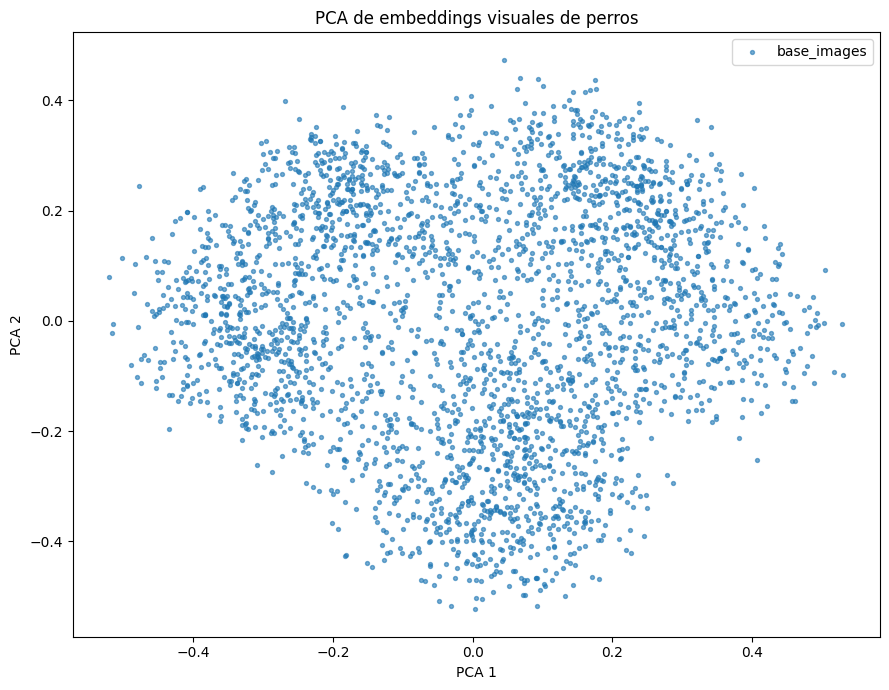

Varianza explicada: [0.05470717 0.05013264]
PCA guardado en: /content/drive/MyDrive/proyecto_integrador_v2/processed_data/metadata/step03_embeddings_pca_sample.csv
Figura PCA guardada en: /content/drive/MyDrive/proyecto_integrador_v2/reports/figures/step03_embedding_pca.png


In [14]:
# 13. PCA exploratorio de embeddings

MAX_PCA_POINTS = 3000

if embeddings_l2.shape[0] > 2:
    sample_size = min(MAX_PCA_POINTS, embeddings_l2.shape[0])
    sample_indices = np.random.choice(embeddings_l2.shape[0], size=sample_size, replace=False)

    sample_embeddings = embeddings_l2[sample_indices]
    sample_metadata = ok_metadata_df.iloc[sample_indices].copy().reset_index(drop=True)

    pca = PCA(n_components=2, random_state=SEED)
    pca_points = pca.fit_transform(sample_embeddings)

    pca_df = sample_metadata.copy()
    pca_df["pca_1"] = pca_points[:, 0]
    pca_df["pca_2"] = pca_points[:, 1]

    PCA_REPORT_PATH = METADATA_PATH / "step03_embeddings_pca_sample.csv"
    pca_df.to_csv(PCA_REPORT_PATH, index=False)

    plt.figure(figsize=(9, 7))

    if "source_type" in pca_df.columns:
        for source_type, group in pca_df.groupby("source_type"):
            plt.scatter(group["pca_1"], group["pca_2"], s=8, alpha=0.6, label=source_type)
        plt.legend()
    else:
        plt.scatter(pca_df["pca_1"], pca_df["pca_2"], s=8, alpha=0.6)

    plt.title("PCA de embeddings visuales de perros")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()

    PCA_FIGURE_PATH = FIGURES_PATH / "step03_embedding_pca.png"
    plt.savefig(PCA_FIGURE_PATH, dpi=150)
    plt.show()

    print("Varianza explicada:", pca.explained_variance_ratio_)
    print("PCA guardado en:", PCA_REPORT_PATH)
    print("Figura PCA guardada en:", PCA_FIGURE_PATH)
else:
    print("No hay suficientes embeddings para PCA.")

In [15]:
# 14. Self-check de consistencia básica

if embeddings_l2.shape[0] > 0:
    norms_l2 = np.linalg.norm(embeddings_l2, axis=1)

    print("Norma L2 mínima:", norms_l2.min())
    print("Norma L2 máxima:", norms_l2.max())
    print("Norma L2 promedio:", norms_l2.mean())

    if np.allclose(norms_l2.mean(), 1.0, atol=1e-3):
        print("OK: los embeddings están normalizados con L2.")
    else:
        print("Advertencia: revisar normalización L2.")
else:
    print("No hay embeddings para validar.")

Norma L2 mínima: 0.9999997
Norma L2 máxima: 1.0000004
Norma L2 promedio: 1.0
OK: los embeddings están normalizados con L2.


# Análisis de métricas del Paso 03

El Paso 03 genera la representación visual principal del sistema.  
Cada crop válido del Paso 02 se convierte en un vector numérico o embedding.

Las métricas principales son:

- **embeddings_generated**: número de crops convertidos correctamente en embeddings.
- **embedding_errors**: imágenes que fallaron durante la extracción.
- **embedding_dimension**: tamaño del vector generado por el modelo.
- **avg_embedding_norm_before_l2**: magnitud promedio antes de normalización.
- **normalization**: confirma que se aplicó normalización L2 para similitud coseno.

La normalización L2 es importante porque en los siguientes pasos se compararán los vectores mediante similitud coseno. Esto permite que la comparación se enfoque en la dirección del vector y no solo en su magnitud.

# Datos finales sobre del Paso 03

Este notebook convierte los crops generados por YOLO en embeddings visuales.

A partir de este punto, cada perro queda representado por un vector comparable.  
Esto permite construir una base de búsqueda visual para encontrar perros similares o posibles coincidencias entre perros perdidos y encontrados.

La raza puede seguir usándose como señal auxiliar en etapas posteriores, pero el componente principal del sistema será la comparación entre embeddings mediante similitud coseno.